In [1]:
import ee
import geemap
import logging
import multiprocessing
import os
import torch
import pandas as pd
from skimage.measure.entropy import shannon_entropy
import numpy as np
import re
import rasterio
import matplotlib.pyplot as plt
import json
from utils.functions import getResult, getRequests, get_files_info
from sklearn.mixture import GaussianMixture
from numpy.linalg import norm

GEE_PROJECT_ID = "fusion-371234"
ee.Authenticate()
ee.Initialize(project=GEE_PROJECT_ID)

# Functions

In [2]:
def compute_ndvi(img, red_idx=3, nir_idx=7):
    red = img[red_idx]
    nir = img[nir_idx]
    ndvi = (nir - red) / (nir + red + 1e-6)
    return ndvi

def get_s2_image(start, end):
    return (
        ee.ImageCollection('COPERNICUS/S2_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start, end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .sort('CLOUDY_PIXEL_PERCENTAGE')
        .first()
        .clip(aoi)
    )

def compute_mean_ndvi_timeseries(path, scale):
    n_files, name_files = get_files_info(path)
    dates = []
    mean_ndvi = []

    for file in sorted(name_files):
        date = os.path.basename(file).split("_")[1].replace(".tif", "")
        dates.append(pd.to_datetime(date))

        with rasterio.open(os.path.join(path, file)) as src:
            red = src.read(4).astype(np.float32) / scale
            nir = src.read(8).astype(np.float32) / scale

            nodata = src.nodata
            if nodata is not None:
                mask = (red == nodata) | (nir == nodata)
                red = np.where(mask, np.nan, red)
                nir = np.where(mask, np.nan, nir)

            denominator = nir + red
            ndvi = np.where(denominator != 0, (nir - red) / denominator, np.nan)

            mean_ndvi.append(np.nanmean(ndvi))

    return dates, mean_ndvi

def compute_mean_lai_timeseries(path, scale):
    n_files, name_files = get_files_info(path)
    dates = []
    mean_lai = []

    for file in sorted(name_files):
        date = os.path.basename(file).split("_")[1].replace(".tif", "")
        dates.append(pd.to_datetime(date))

        with rasterio.open(os.path.join(path, file)) as src:
            red = src.read(4).astype(np.float32) / scale
            nir = src.read(8).astype(np.float32) / scale

            nodata = src.nodata
            if nodata is not None:
                mask = (red == nodata) | (nir == nodata)
                red = np.where(mask, np.nan, red)
                nir = np.where(mask, np.nan, nir)

            denominator = nir + red
            evi = (nir - red) / (nir + red + 1e-6)

            lai = -np.log((0.69 - evi) / 0.59 + 1e-6) / 0.91
            mean_lai.append(np.nanmean(lai))

    return dates, mean_lai


# Study Area

In [10]:
coords = (7.385, -1.356)  # Ejura (lat, lon)

Map = geemap.Map(center=[coords[0], coords[1]], zoom=20)
Map.add_basemap("HYBRID")

aoi = ee.Geometry.Point([coords[1], coords[0]]).buffer(10000)

before_date = ('2018-01-01', '2018-01-07')  # Pre-damage, vegetative stage
after_date  = ('2018-07-01', '2018-09-15')  # Peak FAW damage (composite)


img_before = get_s2_image(*before_date).clip(aoi)
img_after  = get_s2_image(*after_date).clip(aoi)

ndvi_before = img_before.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndvi_after  = img_after.normalizedDifference(['B8', 'B4']).rename('NDVI')

ndvi_diff = ndvi_after.subtract(ndvi_before).rename('NDVI_diff')

# Visualization
rgb_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

ndvi_vis = {
    'min': 0,
    'max': 1,
    'palette': ['brown', 'yellow', 'green']
}

diff_vis = {
    'min': -0.4,
    'max': 0.2,
    'palette': ['red', 'white', 'blue']  
}

# Layers
Map.addLayer(img_before, rgb_vis, 'RGB Before FAW (May 2018)')
Map.addLayer(img_after,  rgb_vis, 'RGB After FAW (Jul–Aug 2018)')
Map.addLayer(ndvi_diff, diff_vis, 'NDVI Difference (FAW impact)')
Map.addLayer(ee.Geometry.Point([coords[1], coords[0]]),
             {"color": "yellow"}, "Ejura AOI")

Map


Map(center=[7.385, -1.356], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=HBox(childr…

In [11]:
# Convert to GeoJSON format
geojson_dict = Map.user_roi.getInfo()
roi_name = "ghana_pest"

# Save to file
with open(f"rois/{roi_name}.json", "w") as f:
    json.dump(geojson_dict, f)

print(f"✅ Region saved as {roi_name}.json")

✅ Region saved as ghana_pest.json


# Before and After Pest Attack

In [31]:
S2_SR_COLLECTION_ID = "COPERNICUS/S2_HARMONIZED"
selected_bands = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']
CLOUD_FILTER = 100
crs = "EPSG:4326"
scale = 10 

before_date = ('2017-01-01', '2017-08-30')
after_date  = ('2017-10-01', '2017-12-30')

DATE = before_date  # change to before_date if needed

roi_name = "rois/ghana_pest"
with open(f"{roi_name}.json", "r") as f:
    region_data = json.load(f)

region = ee.Geometry(region_data)

collection = (
    ee.ImageCollection(S2_SR_COLLECTION_ID)
    .filterDate(DATE[0], DATE[1])
    .filterBounds(region)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER))
    .select(selected_bands)
)

image = collection.median().clip(region)
path = "datasets/ghana_before_and_after"
os.makedirs(path, exist_ok=True)
geemap.ee_export_image(
    image,
    filename=f"{path}/before.tif",
    scale=scale,
    region=region,
    crs=crs,
    file_per_band=False
)

print("✅ Image downloaded exactly as the region geometry.")


Generating URL ...
Please wait ...
Data downloaded to /home/fekenzofugi/Documents/rsad-time-series/datasets/ghana_before_and_after/before.tif
✅ Image downloaded exactly as the region geometry.


In [ ]:
S2_SR_COLLECTION_ID = "COPERNICUS/S2_HARMONIZED"
selected_bands = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']
CLOUD_FILTER = 100
crs = "EPSG:4326"
scale = 10 

before_date = ('2017-01-01', '2017-08-30')
after_date  = ('2017-10-01', '2017-12-30')

DATE = after_date 

roi_name = "rois/ghana_pest"
with open(f"{roi_name}.json", "r") as f:
    region_data = json.load(f)

region = ee.Geometry(region_data)

collection = (
    ee.ImageCollection(S2_SR_COLLECTION_ID)
    .filterDate(DATE[0], DATE[1])
    .filterBounds(region)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER))
    .select(selected_bands)
)

image = collection.median().clip(region)

path = "datasets/ghana_before_and_after"
os.makedirs(path, exist_ok=True)
geemap.ee_export_image(
    image,
    filename=f"{path}/after.tif",
    scale=scale,
    region=region,
    crs=crs,
    file_per_band=False
)

print("✅ Image downloaded exactly as the region geometry.")


Generating URL ...
Please wait ...
Data downloaded to /home/fekenzofugi/Documents/rsad-time-series/datasets/ghana_before_and_after/after.tif
✅ Image downloaded exactly as the region geometry.


# Generate Time-Series

In [16]:
S2_SR_COLLECTION_ID = "COPERNICUS/S2_HARMONIZED"

selected_bands = ['B1','B2','B3','B4','B5','B6', 'B7','B8','B8A','B9','B11','B12']

CLOUD_FILTER = 100 # 100 = No Filter, 0 = Full Filter
crs = "EPSG:4326"
scale = 10 # for Sentinel-2 is 10 meters resolution

year = 2021
start_date = f'{year}-01-01'
end_date   = f'{year}-12-31'

roi_name = f"ghana_pest"
with open(f"rois/{roi_name}.json", "r") as f:
    region_data = json.load(f)

region = ee.Geometry(region_data)
collection = (
    ee.ImageCollection(S2_SR_COLLECTION_ID)
    .filterDate(start_date, end_date)
    .filterBounds(region)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER))
    .select(selected_bands)
    .sort('system:time_start')
)

print("Number of images:", collection.size().getInfo())

os.makedirs(f"datasets/{year}_{roi_name}_time_series", exist_ok=True)

image_list = collection.toList(collection.size())
n_images = collection.size().getInfo()

for i in range(n_images):
    img = ee.Image(image_list.get(i))
    date = ee.Date(img.get('system:time_start')).format('YYYYMMdd').getInfo()
    filename = f"datasets/{year}_{roi_name}_time_series/S2_{date}.tif"
    geemap.ee_export_image(
        img.clip(region),
        filename=filename,
        scale=scale,
        region=region,
        crs=crs,
        file_per_band=False
    )
    print(f"✅ Exported {filename}")

Number of images: 75
Generating URL ...
Please wait ...
Data downloaded to /home/fekenzofugi/Documents/rsad-time-series/datasets/2021_ghana_pest_time_series/S2_20210101.tif
✅ Exported datasets/2021_ghana_pest_time_series/S2_20210101.tif
Generating URL ...
Please wait ...
Data downloaded to /home/fekenzofugi/Documents/rsad-time-series/datasets/2021_ghana_pest_time_series/S2_20210106.tif
✅ Exported datasets/2021_ghana_pest_time_series/S2_20210106.tif
Generating URL ...
Please wait ...
Data downloaded to /home/fekenzofugi/Documents/rsad-time-series/datasets/2021_ghana_pest_time_series/S2_20210111.tif
✅ Exported datasets/2021_ghana_pest_time_series/S2_20210111.tif
Generating URL ...
Please wait ...
Data downloaded to /home/fekenzofugi/Documents/rsad-time-series/datasets/2021_ghana_pest_time_series/S2_20210116.tif
✅ Exported datasets/2021_ghana_pest_time_series/S2_20210116.tif
Generating URL ...
Please wait ...
Data downloaded to /home/fekenzofugi/Documents/rsad-time-series/datasets/2021_gh

# Plots

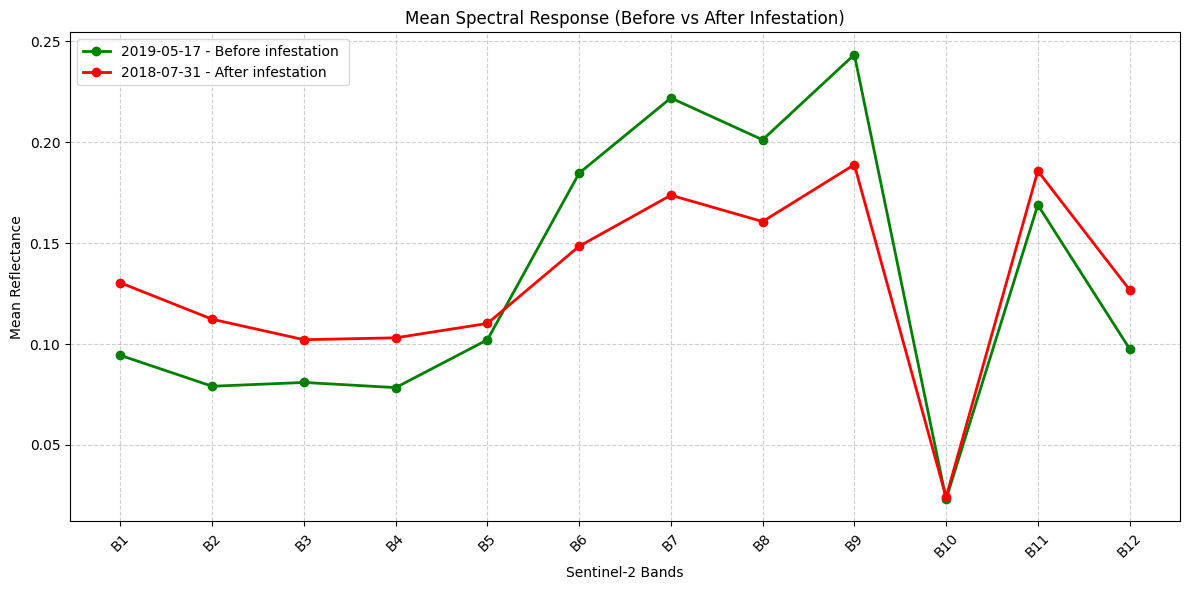

In [26]:
scale = 10000

before_date = ('2019-05-17', '2018-10-25')
after_date  = ('2018-07-31', '2018-07-31')

before_path = "datasets/2019_ghana_pest_time_series/S2_20190517.tif"
after_path  = "datasets/2019_ghana_pest_time_series/S2_20190731.tif"

with rasterio.open(before_path) as src:
    img_before = src.read() / scale
    n_bands = img_before.shape[0]

with rasterio.open(after_path) as src:
    img_after = src.read() / scale

mean_before = np.nanmean(img_before.reshape(n_bands, -1), axis=1)
mean_after  = np.nanmean(img_after.reshape(n_bands, -1), axis=1)

bands = np.arange(1, n_bands + 1)
band_labels = [f"B{i}" for i in bands]


plt.figure(figsize=(12, 6))

plt.plot(bands, mean_before, "o-", linewidth=2, label=f"{before_date[0]} - Before infestation ", color="green")
plt.plot(bands, mean_after,  "o-", linewidth=2, label=f"{after_date[0]} - After infestation ", color="red")

plt.xticks(bands, band_labels, rotation=45)
plt.xlabel("Sentinel-2 Bands")
plt.ylabel("Mean Reflectance")
plt.title("Mean Spectral Response (Before vs After Infestation)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc='upper left')
# plt.savefig("figures/india_spectral_response_before_after_infestation.png", dpi=300)
plt.tight_layout()
plt.show()


## Crops Time-Series

Total number of files: 40


/tmp/ipykernel_8194/1564630071.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1.0])


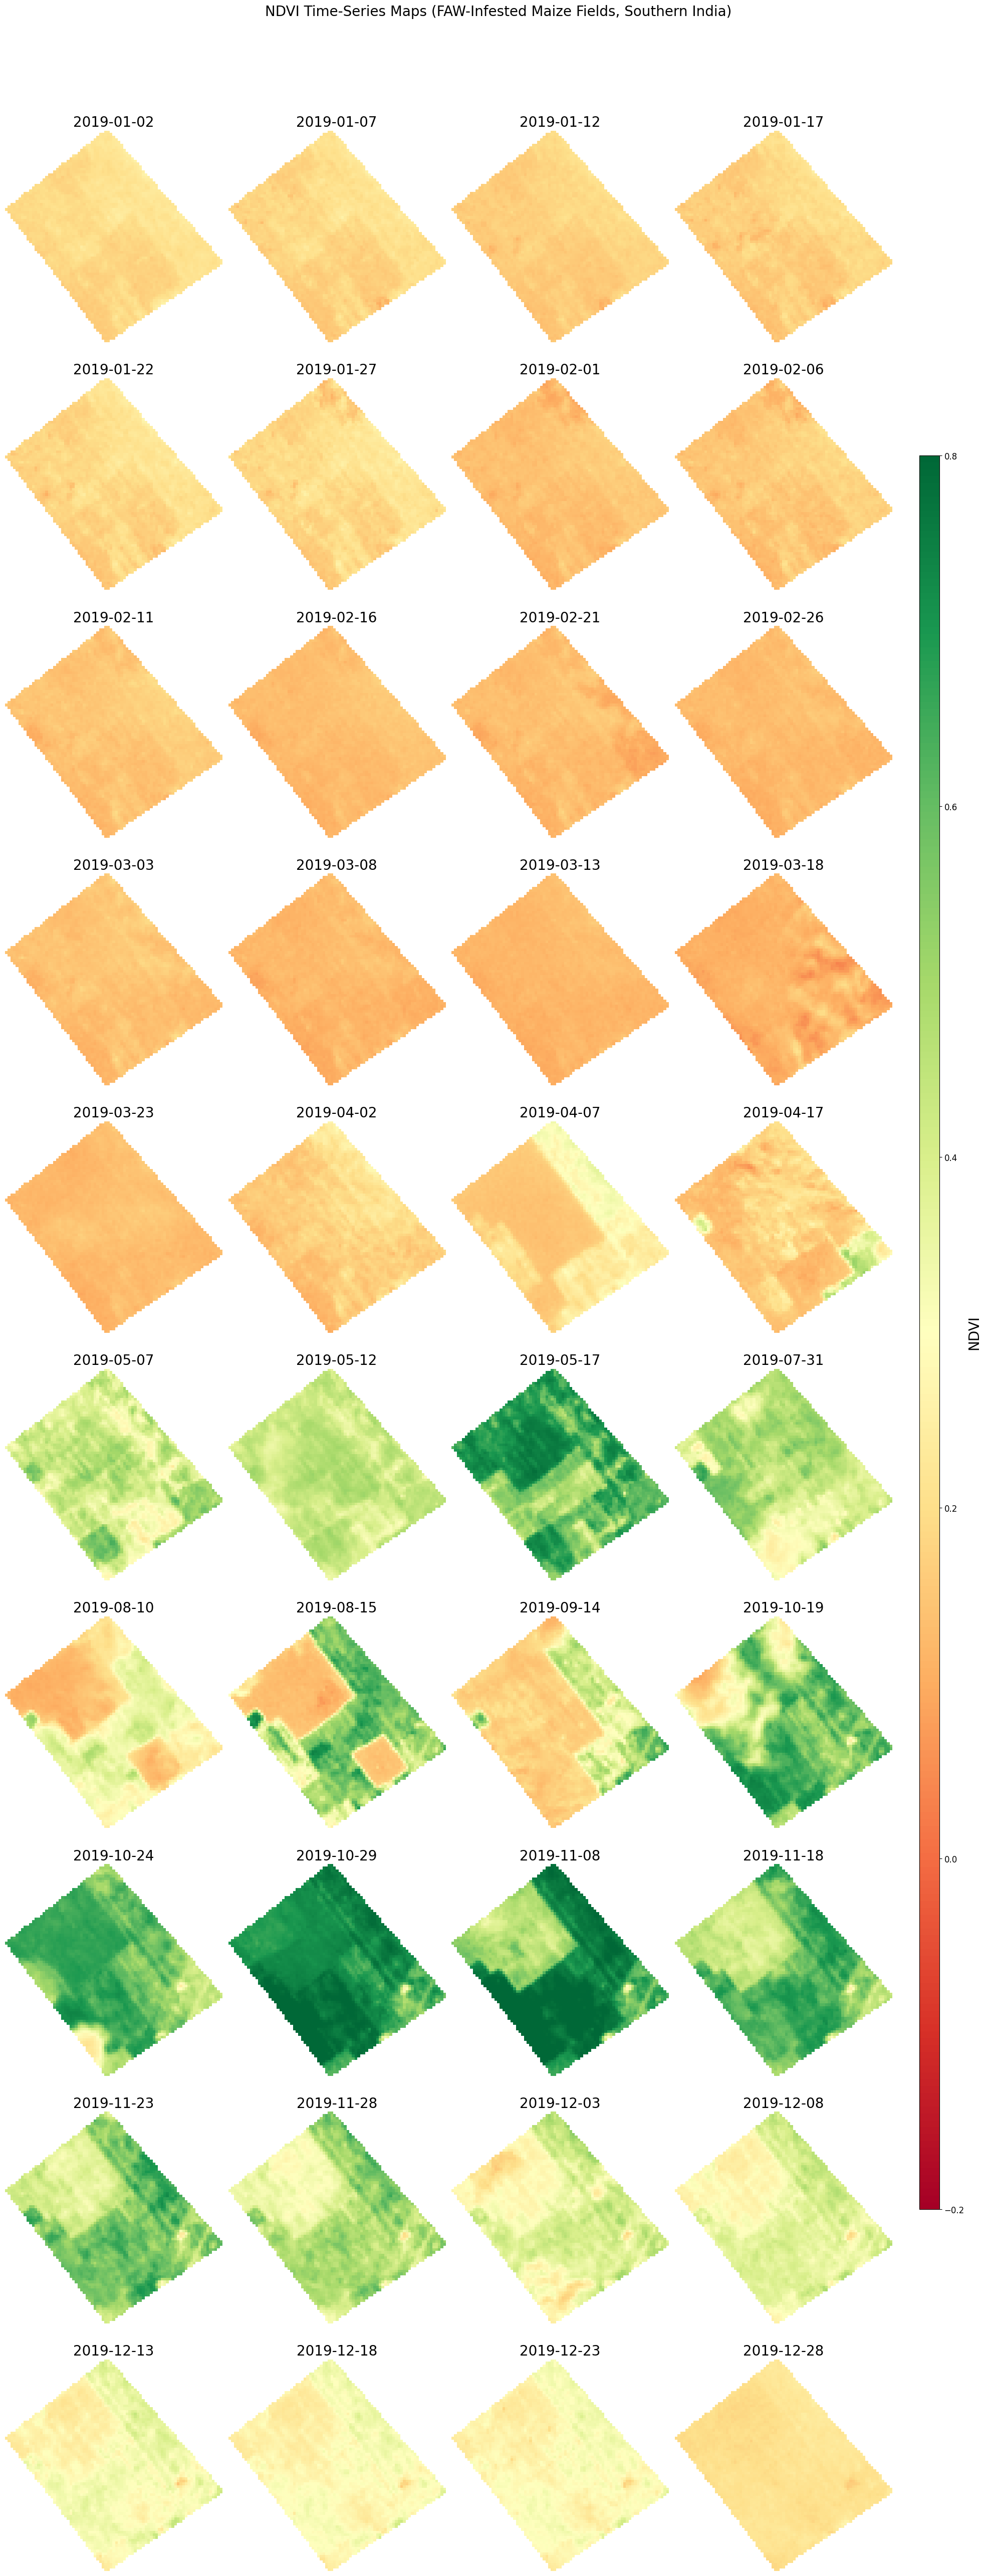

In [43]:
path = "datasets/2019_ghana_pest_time_series"
scale = 10000

n_files, name_files = get_files_info(path)
name_files = sorted(name_files)

ndvi_maps = []
dates = []

for file in name_files:
    date = os.path.basename(file).split("_")[1].replace(".tif", "")
    dates.append(pd.to_datetime(date))

    with rasterio.open(os.path.join(path, file)) as src:
        red = src.read(4).astype(np.float32) / scale
        nir = src.read(8).astype(np.float32) / scale

        nodata = src.nodata
        if nodata is not None:
            red = np.where(red == nodata, np.nan, red)
            nir = np.where(nir == nodata, np.nan, nir)

        ndvi = (nir - red) / (nir + red)
        ndvi[(nir + red) == 0] = np.nan

        ndvi_maps.append(ndvi)

ndvi_maps = np.array(ndvi_maps)

n_images = len(ndvi_maps)
n_cols = 4
n_rows = int(np.ceil(n_images / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 5 * n_rows),  # <-- increased
    squeeze=False
)

for i, ax in enumerate(axes.flat):
    if i < n_images:
        im = ax.imshow(
            ndvi_maps[i],
            cmap="RdYlGn",
            vmin=-0.2,
            vmax=0.8
        )
        ax.set_title(
            dates[i].strftime("%Y-%m-%d"),
            fontsize=20,          
            pad=6
        )
        ax.axis("off")
    else:
        ax.axis("off")

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("NDVI", fontsize=20)
cbar.ax.tick_params(labelsize=12)

plt.suptitle(
    "NDVI Time-Series Maps (FAW-Infested Maize Fields, Southern India)",
    fontsize=20,
    y=1.03 
)

plt.tight_layout(rect=[0, 0, 0.9, 1.0])  

# plt.savefig(
#     "figures/india_ndvi_time_series_maps.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()


Total number of files: 41


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2234].


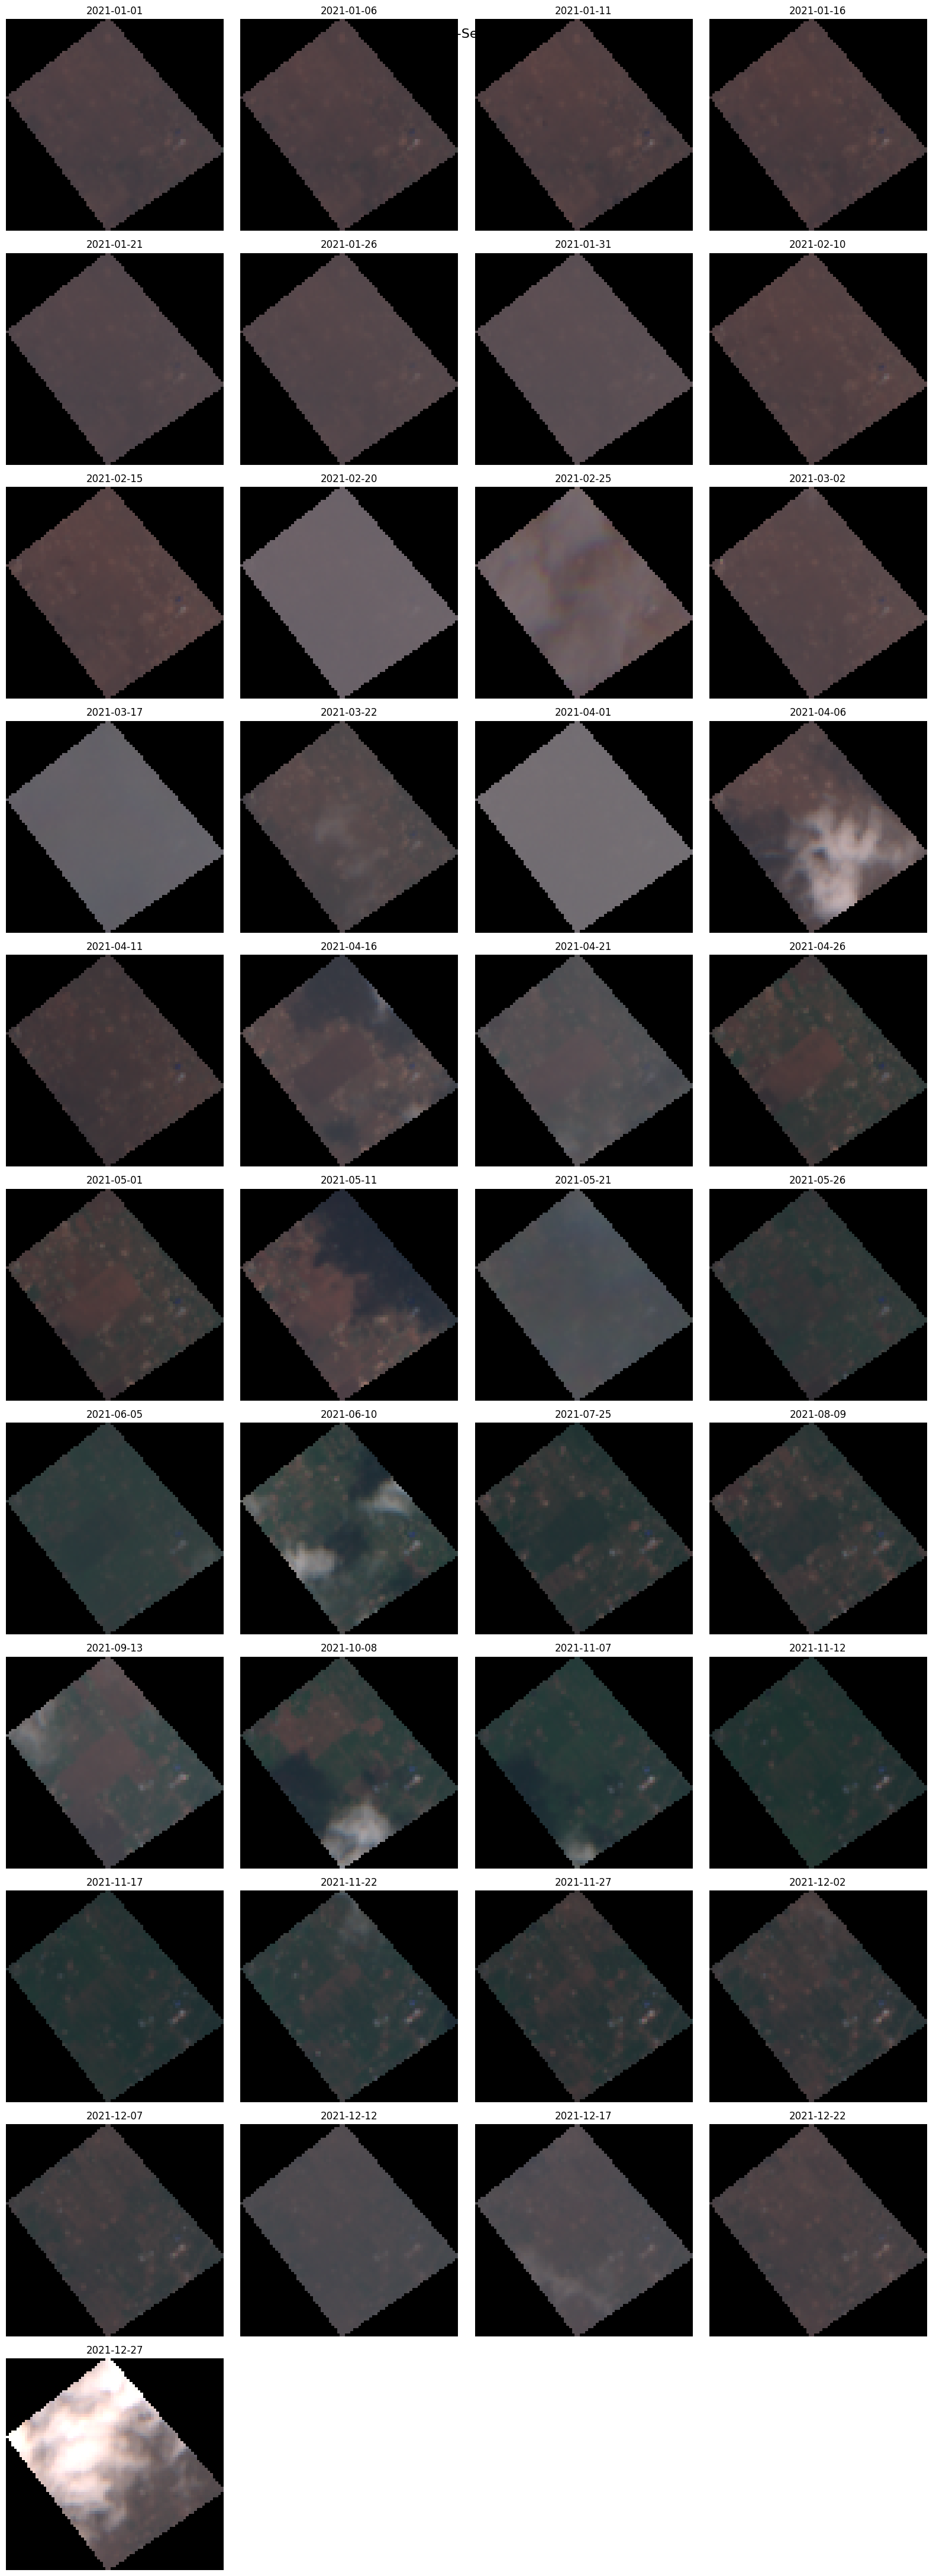

In [39]:
path = "datasets/2021_ghana_pest_time_series"
scale = 5000

n_files, name_files = get_files_info(path)
name_files = sorted(name_files)

rgb_maps = []
dates = []

for file in name_files:
    date = os.path.basename(file).split("_")[1].replace(".tif", "")
    dates.append(pd.to_datetime(date))

    with rasterio.open(os.path.join(path, file)) as src:
        red = src.read(4).astype(np.float32) / scale
        green = src.read(3).astype(np.float32) / scale
        blue = src.read(2).astype(np.float32) / scale

        nodata = src.nodata
        if nodata is not None:
            red = np.where(red == nodata, 0, red)
            green = np.where(green == nodata, 0, green)
            blue = np.where(blue == nodata, 0, blue)

        rgb = np.dstack([red, green, blue])
        rgb_maps.append(rgb)

rgb_maps = np.array(rgb_maps)

n_images = len(rgb_maps)
n_cols = 4
n_rows = int(np.ceil(n_images / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 4 * n_rows),
    squeeze=False
)

for i, ax in enumerate(axes.flat):
    if i < n_images:
        ax.imshow(rgb_maps[i])
        ax.set_title(dates[i].strftime("%Y-%m-%d"))
        ax.axis("off")
    else:
        ax.axis("off")

plt.suptitle("RGB Time-Series Maps", fontsize=16)
plt.tight_layout()
plt.show()


## Per Year Plots

For each pixel in the figure, we generate the time-series of it, with its mean, median and variance. We're expecting a higher variance to the fields over pest-infestation

In [ ]:
scale = 10000
years = [2017, 2018, 2019, 2020, 2021]

for year in years:

    print(f"\nProcessing {year}")

    ndvi_time_series = []

    path = f"datasets/{year}_ghana_pest_time_series"
    n_files, name_files = get_files_info(path)

    name_files = sorted(name_files)

    for file in name_files:

        date = os.path.basename(file).split("_")[1].replace(".tif", "")
        print(f"  Reading {date}")

        with rasterio.open(os.path.join(path, file)) as src:
            red = src.read(4).astype(np.float32) / scale   
            nir = src.read(8).astype(np.float32) / scale   

            nodata = src.nodata
            if nodata is not None:
                mask = (red == nodata) | (nir == nodata)
                red[mask] = np.nan
                nir[mask] = np.nan

            # NDVI (correct formula)
            ndvi = np.where(
                (nir + red) != 0,
                (nir - red) / (nir + red),
                np.nan
            )

        ndvi_time_series.append(ndvi)

    ndvi_cube = np.array(ndvi_time_series)

    T, H, W = ndvi_cube.shape
    print("NDVI cube:", ndvi_cube.shape)

    # (T, H, W) -> (H*W, T)
    pixels_ts = ndvi_cube.reshape(T, -1).T

    valid = ~np.all(np.isnan(pixels_ts), axis=1)
    pixels_ts = pixels_ts[valid]

    print("Valid pixels:", pixels_ts.shape[0])

    plt.figure(figsize=(10, 6))

    for ts in pixels_ts:
        plt.plot(ts, color="green", alpha=0.1)

    plt.title(f"NDVI pixel time series - {year}")
    plt.xlabel("Time index")
    plt.ylabel("NDVI")
    plt.grid(alpha=0.2)
    plt.show()

    mean_ts = np.nanmean(pixels_ts, axis=0)
    median_ts = np.nanmedian(pixels_ts, axis=0)
    var_ts = np.nanvar(pixels_ts, axis=0)
    std_ts = np.sqrt(var_ts)

    plt.figure(figsize=(10, 6))

    plt.plot(mean_ts, label="Mean NDVI",   color="black", linewidth=2)
    plt.plot(median_ts, label="Median NDVI", color="red",   linewidth=2)

    plt.fill_between(
        range(T),
        mean_ts - std_ts,
        mean_ts + std_ts,
        alpha=0.3,
        label="±1σ (spatial variability)"
    )

    plt.title(f"NDVI temporal statistics – {year}")
    plt.xlabel("Time index")
    plt.ylabel("NDVI")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


Processing 2017
Total number of files: 31
Total scenes: 31
  Reading 2017-01-07
  Reading 2017-01-27
  Reading 2017-02-06
  Reading 2017-02-16
  Reading 2017-02-26
  Reading 2017-03-08
  Reading 2017-03-18
  Reading 2017-03-28
  Reading 2017-04-07
  Reading 2017-04-17
  Reading 2017-04-27
  Reading 2017-05-07
  Reading 2017-05-17
  Reading 2017-07-01
  Reading 2017-07-11
  Reading 2017-07-21
  Reading 2017-08-15
  Reading 2017-09-14
  Reading 2017-10-04
  Reading 2017-10-09
  Reading 2017-10-14
  Reading 2017-10-19
  Reading 2017-11-03
  Reading 2017-11-08
  Reading 2017-11-13
  Reading 2017-11-18
  Reading 2017-12-03
  Reading 2017-12-08
  Reading 2017-12-18
  Reading 2017-12-23
  Reading 2017-12-28
NDVI cube: (31, 79, 81)
Valid pixels: 3274


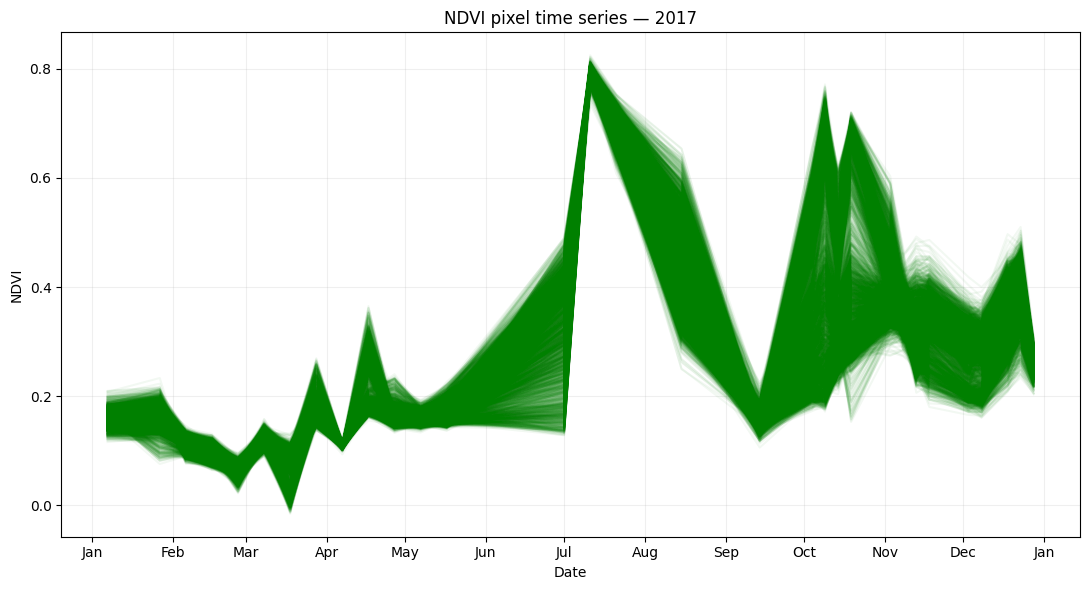

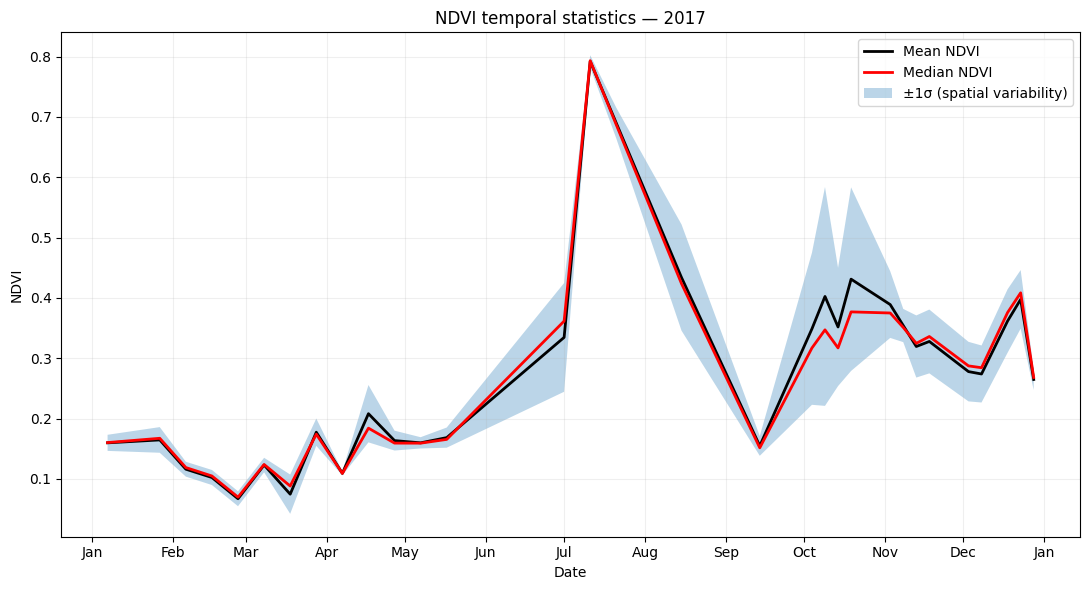


Processing 2018
Total number of files: 34
Total scenes: 34
  Reading 2018-01-02
  Reading 2018-01-07
  Reading 2018-01-12
  Reading 2018-01-17
  Reading 2018-01-22
  Reading 2018-01-27
  Reading 2018-02-01
  Reading 2018-02-06
  Reading 2018-02-11
  Reading 2018-02-16
  Reading 2018-03-03
  Reading 2018-03-18
  Reading 2018-03-23
  Reading 2018-04-17
  Reading 2018-04-22
  Reading 2018-04-27
  Reading 2018-05-02
  Reading 2018-05-07
  Reading 2018-05-17
  Reading 2018-06-26
  Reading 2018-08-05
  Reading 2018-08-15
  Reading 2018-09-14
  Reading 2018-09-29
  Reading 2018-10-24
  Reading 2018-11-08
  Reading 2018-11-18
  Reading 2018-11-28
  Reading 2018-12-03
  Reading 2018-12-08
  Reading 2018-12-13
  Reading 2018-12-18
  Reading 2018-12-23
  Reading 2018-12-28
NDVI cube: (34, 79, 81)
Valid pixels: 3274


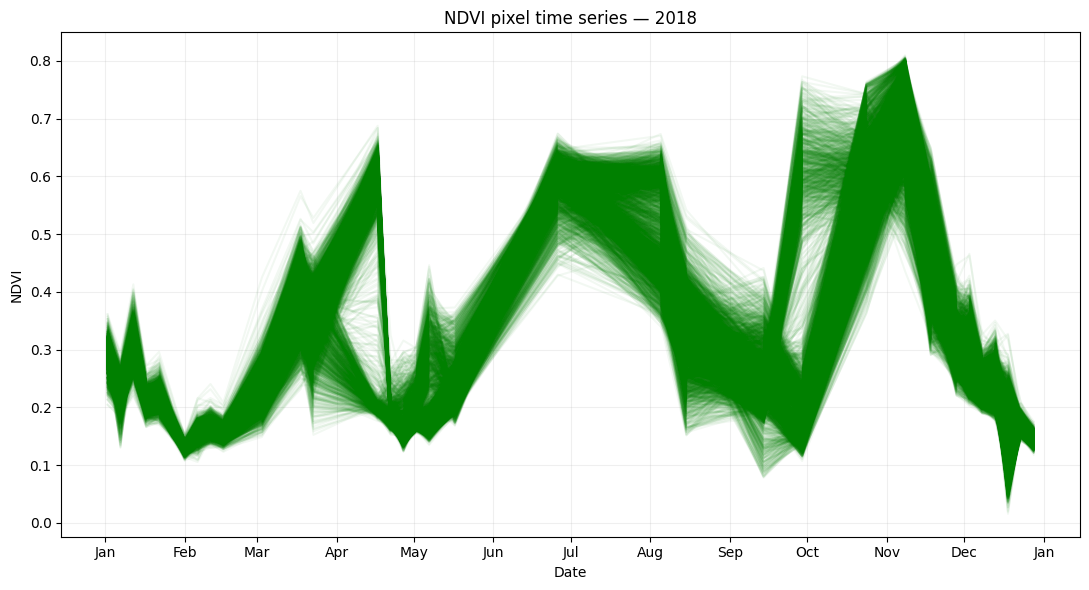

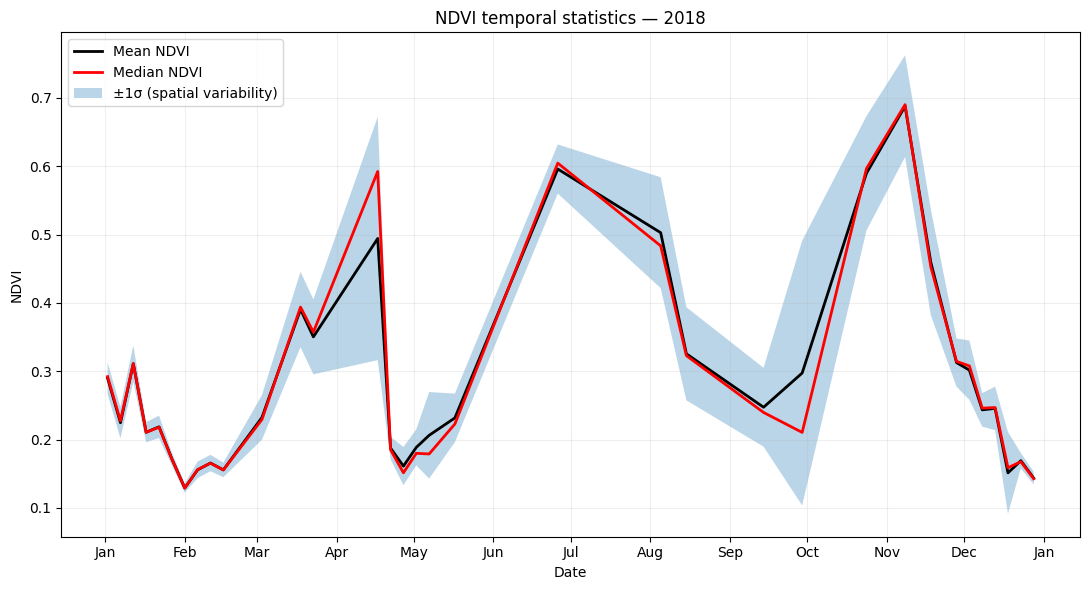


Processing 2019
Total number of files: 40
Total scenes: 40
  Reading 2019-01-02
  Reading 2019-01-07
  Reading 2019-01-12
  Reading 2019-01-17
  Reading 2019-01-22
  Reading 2019-01-27
  Reading 2019-02-01
  Reading 2019-02-06
  Reading 2019-02-11
  Reading 2019-02-16
  Reading 2019-02-21
  Reading 2019-02-26
  Reading 2019-03-03
  Reading 2019-03-08
  Reading 2019-03-13
  Reading 2019-03-18
  Reading 2019-03-23
  Reading 2019-04-02
  Reading 2019-04-07
  Reading 2019-04-17
  Reading 2019-05-07
  Reading 2019-05-12
  Reading 2019-05-17
  Reading 2019-07-31
  Reading 2019-08-10
  Reading 2019-08-15
  Reading 2019-09-14
  Reading 2019-10-19
  Reading 2019-10-24
  Reading 2019-10-29
  Reading 2019-11-08
  Reading 2019-11-18
  Reading 2019-11-23
  Reading 2019-11-28
  Reading 2019-12-03
  Reading 2019-12-08
  Reading 2019-12-13
  Reading 2019-12-18
  Reading 2019-12-23
  Reading 2019-12-28
NDVI cube: (40, 79, 81)
Valid pixels: 3274


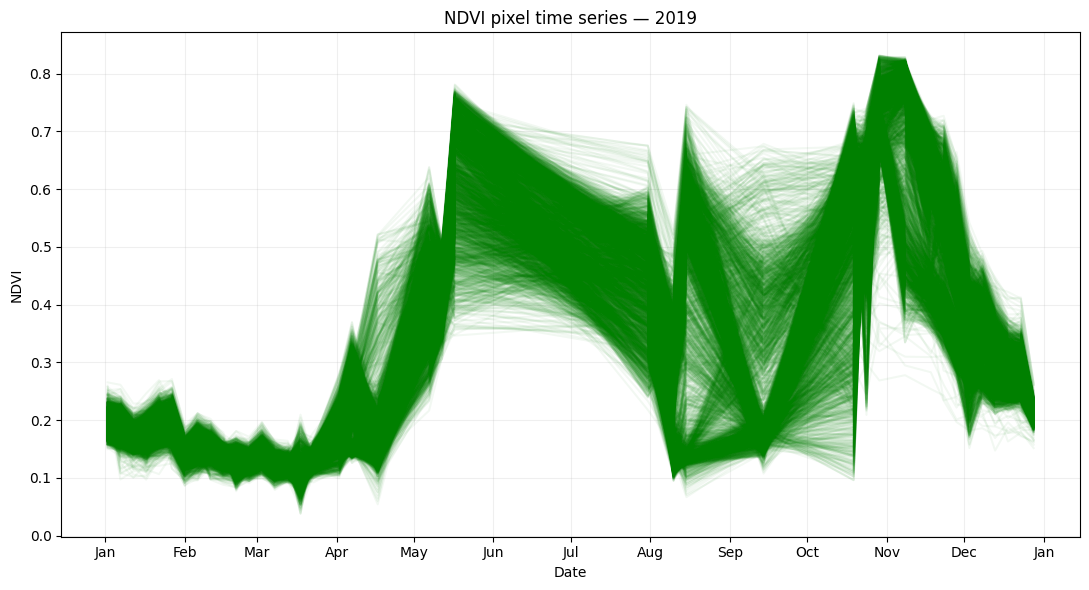

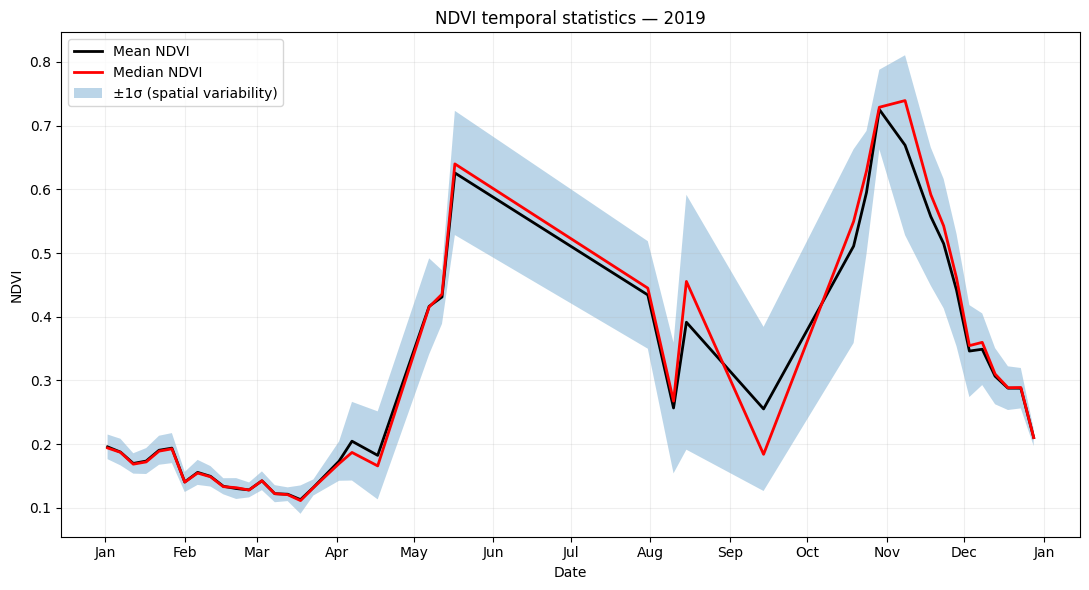


Processing 2020
Total number of files: 46
Total scenes: 46
  Reading 2020-01-02
  Reading 2020-01-07
  Reading 2020-01-12
  Reading 2020-01-17
  Reading 2020-01-27
  Reading 2020-02-01
  Reading 2020-02-06
  Reading 2020-02-11
  Reading 2020-02-16
  Reading 2020-02-21
  Reading 2020-02-26
  Reading 2020-03-02
  Reading 2020-03-07
  Reading 2020-03-12
  Reading 2020-03-17
  Reading 2020-03-22
  Reading 2020-03-27
  Reading 2020-04-06
  Reading 2020-04-11
  Reading 2020-04-16
  Reading 2020-04-21
  Reading 2020-05-01
  Reading 2020-05-06
  Reading 2020-05-16
  Reading 2020-05-21
  Reading 2020-05-26
  Reading 2020-06-05
  Reading 2020-07-15
  Reading 2020-07-30
  Reading 2020-08-04
  Reading 2020-09-18
  Reading 2020-09-28
  Reading 2020-10-13
  Reading 2020-10-28
  Reading 2020-11-02
  Reading 2020-11-07
  Reading 2020-11-12
  Reading 2020-11-17
  Reading 2020-11-22
  Reading 2020-11-27
  Reading 2020-12-02
  Reading 2020-12-07
  Reading 2020-12-12
  Reading 2020-12-17
  Reading 2020-1

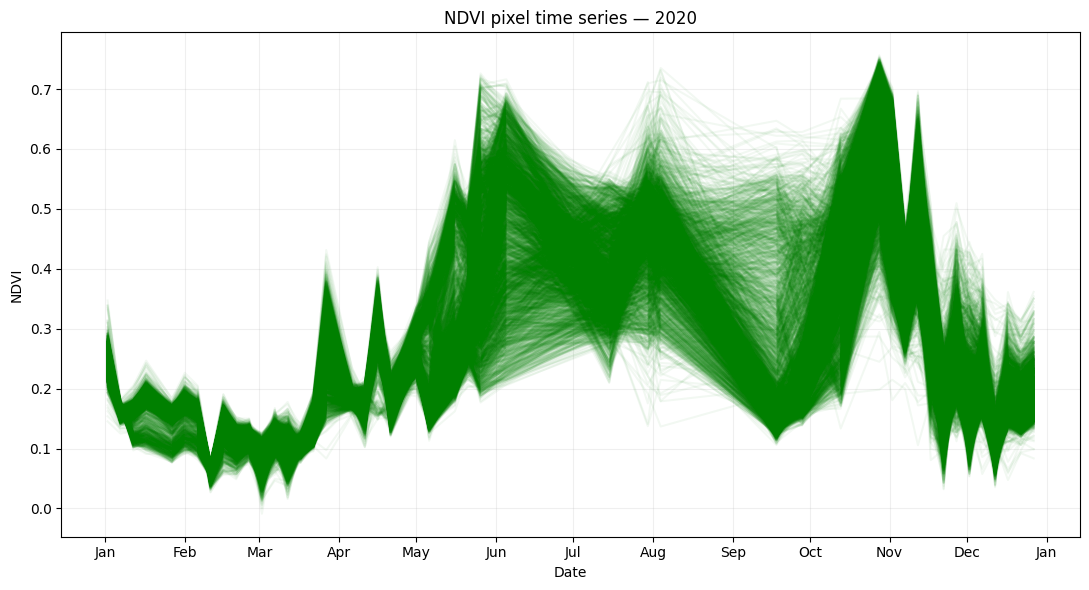

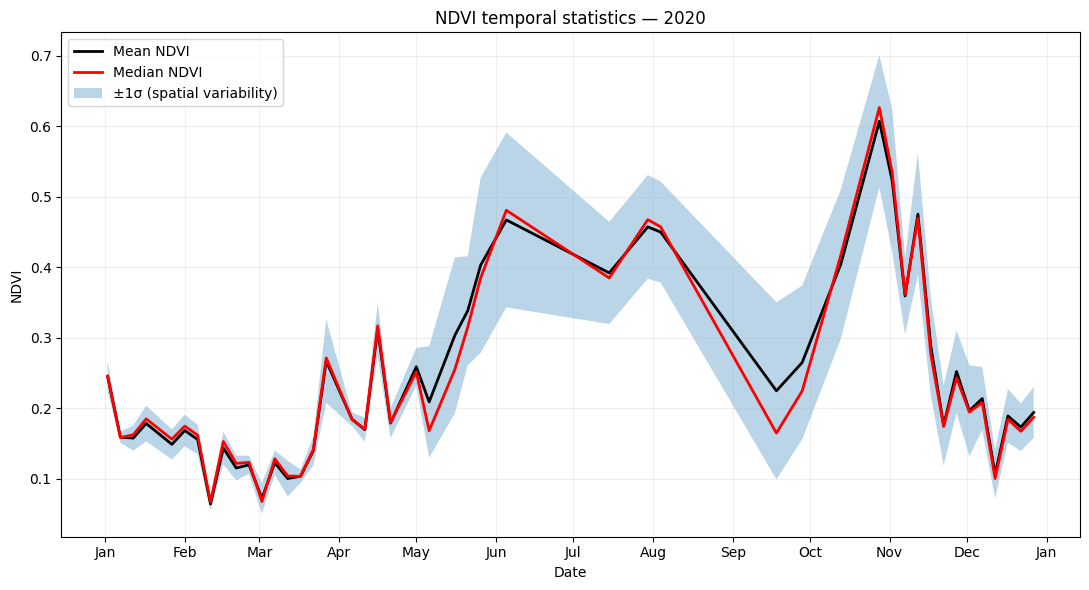


Processing 2021
Total number of files: 41
Total scenes: 41
  Reading 2021-01-01
  Reading 2021-01-06
  Reading 2021-01-11
  Reading 2021-01-16
  Reading 2021-01-21
  Reading 2021-01-26
  Reading 2021-01-31
  Reading 2021-02-10
  Reading 2021-02-15
  Reading 2021-02-20
  Reading 2021-02-25
  Reading 2021-03-02
  Reading 2021-03-17
  Reading 2021-03-22
  Reading 2021-04-01
  Reading 2021-04-06
  Reading 2021-04-11
  Reading 2021-04-16
  Reading 2021-04-21
  Reading 2021-04-26
  Reading 2021-05-01
  Reading 2021-05-11
  Reading 2021-05-21
  Reading 2021-05-26
  Reading 2021-06-05
  Reading 2021-06-10
  Reading 2021-07-25
  Reading 2021-08-09
  Reading 2021-09-13
  Reading 2021-10-08
  Reading 2021-11-07
  Reading 2021-11-12
  Reading 2021-11-17
  Reading 2021-11-22
  Reading 2021-11-27
  Reading 2021-12-02
  Reading 2021-12-07
  Reading 2021-12-12
  Reading 2021-12-17
  Reading 2021-12-22
  Reading 2021-12-27
NDVI cube: (41, 79, 81)
Valid pixels: 3274


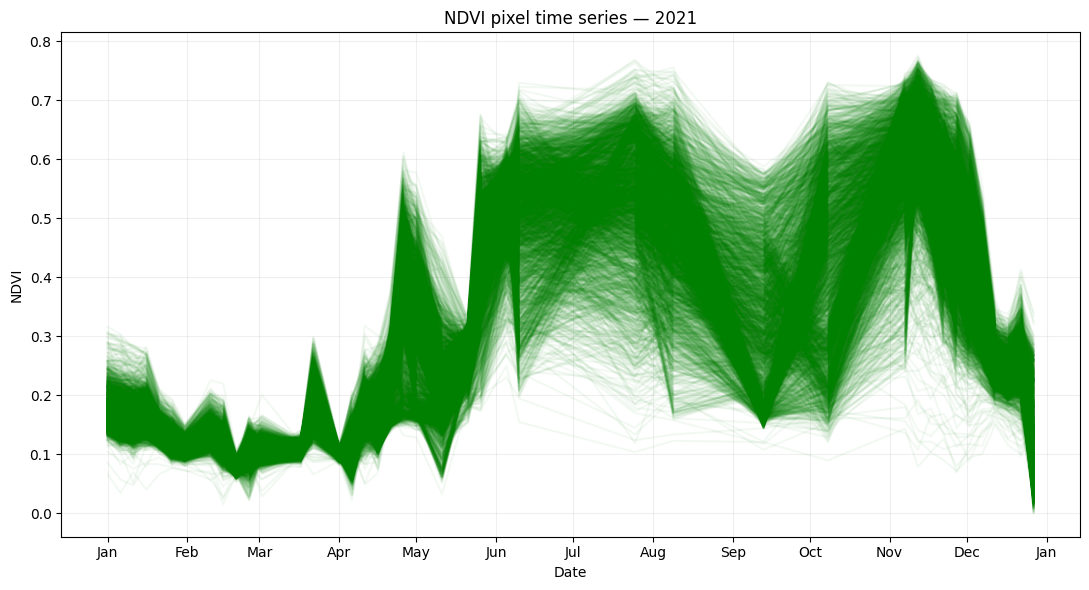

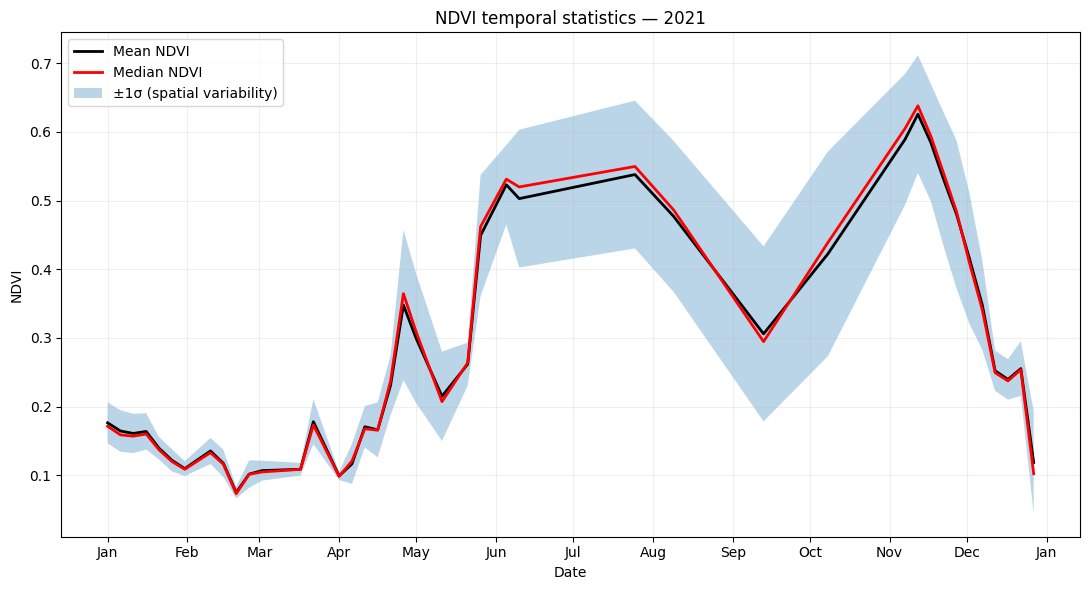

In [40]:
import matplotlib.dates as mdates
from datetime import datetime

scale = 10000
years = [2017, 2018, 2019, 2020, 2021]

for year in years:

    print(f"\nProcessing {year}")

    ndvi_time_series = []
    dates = []

    path = f"datasets/{year}_ghana_pest_time_series"
    n_files, name_files = get_files_info(path)

    file_date_pairs = []
    for file in name_files:
        date_str = os.path.basename(file).split("_")[1].replace(".tif", "")
        date = datetime.strptime(date_str, "%Y%m%d")
        file_date_pairs.append((file, date))

    file_date_pairs.sort(key=lambda x: x[1])

    print(f"Total scenes: {len(file_date_pairs)}")

    for file, date in file_date_pairs:

        print(f"  Reading {date.strftime('%Y-%m-%d')}")

        with rasterio.open(os.path.join(path, file)) as src:
            red = src.read(4).astype(np.float32) / scale
            nir = src.read(8).astype(np.float32) / scale

            nodata = src.nodata
            if nodata is not None:
                mask = (red == nodata) | (nir == nodata)
                red[mask] = np.nan
                nir[mask] = np.nan

            ndvi = np.where(
                (nir + red) != 0,
                (nir - red) / (nir + red),
                np.nan
            )

        ndvi_time_series.append(ndvi)
        dates.append(date)

    ndvi_cube = np.array(ndvi_time_series)
    T, H, W = ndvi_cube.shape
    print("NDVI cube:", ndvi_cube.shape)

    # (T, H, W) → (Npixels, T)
    pixels_ts = ndvi_cube.reshape(T, -1).T

    valid = ~np.all(np.isnan(pixels_ts), axis=1)
    pixels_ts = pixels_ts[valid]

    print("Valid pixels:", pixels_ts.shape[0])

    plt.figure(figsize=(11, 6))

    for ts in pixels_ts:
        plt.plot(dates, ts, color="green", alpha=0.05)

    plt.title(f"NDVI pixel time series — {year}")
    plt.xlabel("Date")
    plt.ylabel("NDVI")

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    mean_ts = np.nanmean(pixels_ts, axis=0)
    median_ts = np.nanmedian(pixels_ts, axis=0)
    std_ts = np.nanstd(pixels_ts, axis=0)

    plt.figure(figsize=(11, 6))

    plt.plot(dates, mean_ts, label="Mean NDVI", color="black", linewidth=2)
    plt.plot(dates, median_ts, label="Median NDVI", color="red", linewidth=2)

    plt.fill_between(
        dates,
        mean_ts - std_ts,
        mean_ts + std_ts,
        alpha=0.3,
        label="±1σ (spatial variability)"
    )

    plt.title(f"NDVI temporal statistics — {year}")
    plt.xlabel("Date")
    plt.ylabel("NDVI")

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()

    # plt.savefig(f"figures/ndvi_timeseries_{year}.png", dpi=200)
    plt.show()
